In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams['pdf.fonttype'] = 42

plt.figure(figsize=(20, 20))

In [ ]:
adata = sc.read('/projects/0/einf2548/cruiz/dmg/data/beyond/subpopulation.proportions.h5ad')
adata

AnnData object with n_obs × n_vars = 83 × 16
    obs: 'Study', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'clusters', 'Material'
    var: 'class', 'grouping.by', 'cell.type', 'community', 'sub.community'
    uns: 'cell.types', 'communities', 'leiden', 'leiden_R', 'neighbors', 'ss.cor', 'trajectories'
    obsm: 'X_all_3d_phate', 'X_phate', 'X_tsne', 'X_umap', 'communities', 'sub.communities'
    layers: 'counts', 'sqrt.prev'
    obsp: 'connectivities', 'distances', 'similarity_X_all_3d_phate', 'similarity_X_tsne', 'similarity_X_umap'

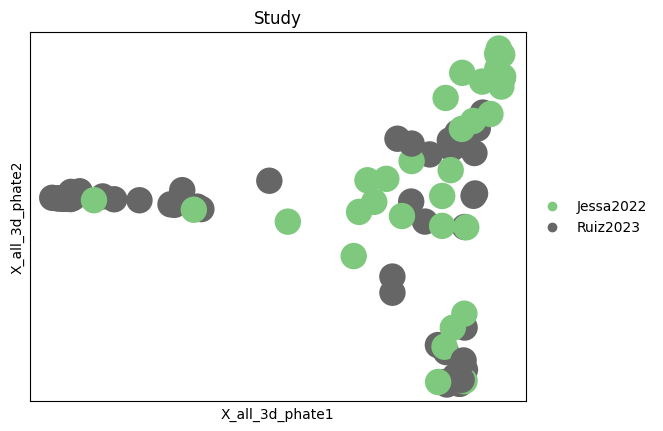

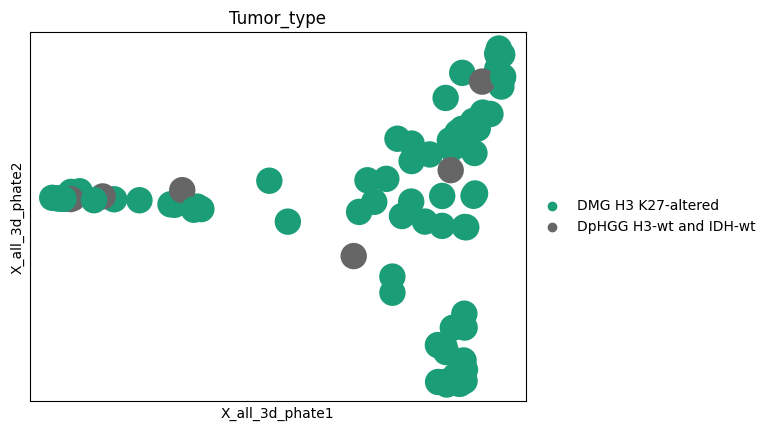

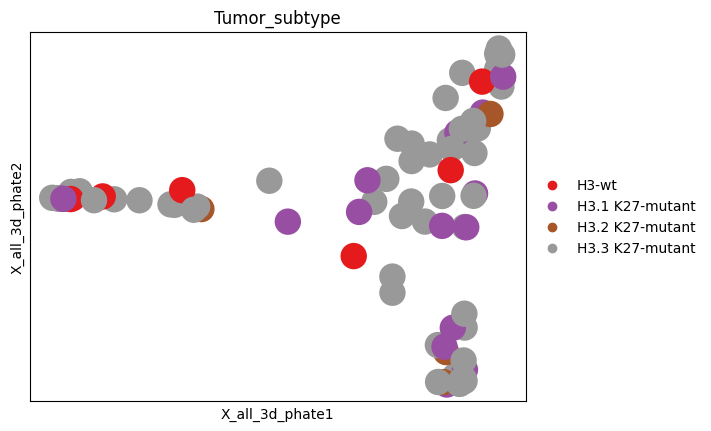

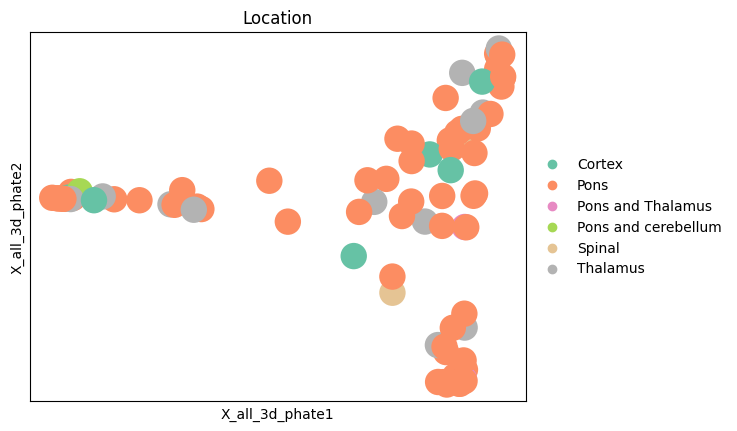

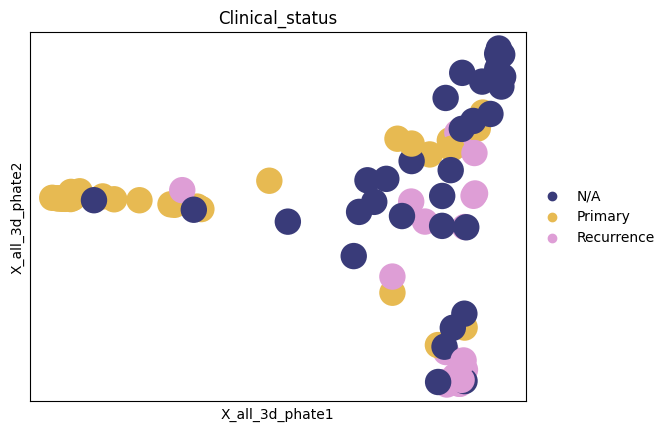

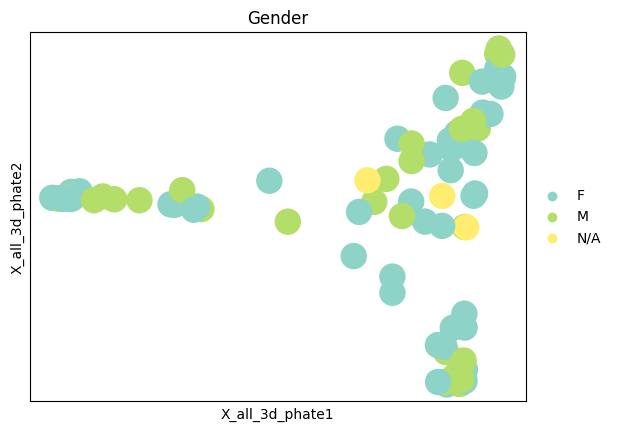

In [ ]:
palettes = ['Accent', 'Dark2',
                      'Set1', 'Set2','tab20b', 'Set3', ]

categorical_columns = ['Study', 'Tumor_type', 'Tumor_subtype', 'Location', 'Clinical_status',  'Gender']

for i, col in enumerate(categorical_columns):
    
    sc.pl.embedding(adata, 'X_all_3d_phate', color=[col], 
                    palette=palettes[i],show=True)
    
    # Save the plot
    # plt.savefig(f"figures/{col}_embedding_{palette_name}.pdf")
    plt.close()

In [ ]:
import matplotlib

# Predefined list of palettes
palettes = ['Accent', 'Dark2',
                      'Set1', 'Set2','tab20b', 'Set3', ]

# Get all categorical columns in adata.obs
categorical_columns = ['Study', 'Tumor_type', 'Tumor_subtype', 'Location', 'Clinical_status',  'Gender']

# Loop through each categorical column
for i, col in enumerate(categorical_columns):
    # Plot the embedding
    sc.pl.embedding(adata, 'X_all_3d_phate', color=[col], 
                    palette=palettes[i],show=False)
    
    # Save the plot
    plt.savefig(f"figures/{col}_embedding.pdf")
    plt.close()

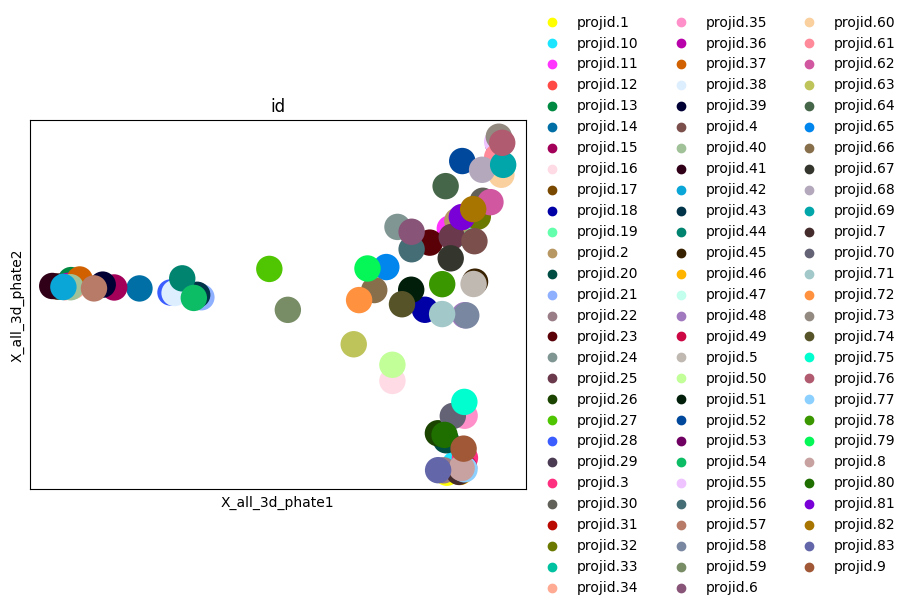

In [ ]:
adata.obs['id'] = pd.Categorical(adata.obs_names.to_list())
sc.pl.embedding(adata, 'X_all_3d_phate', color =['id'], save='figures/donor_embedding.pdf')

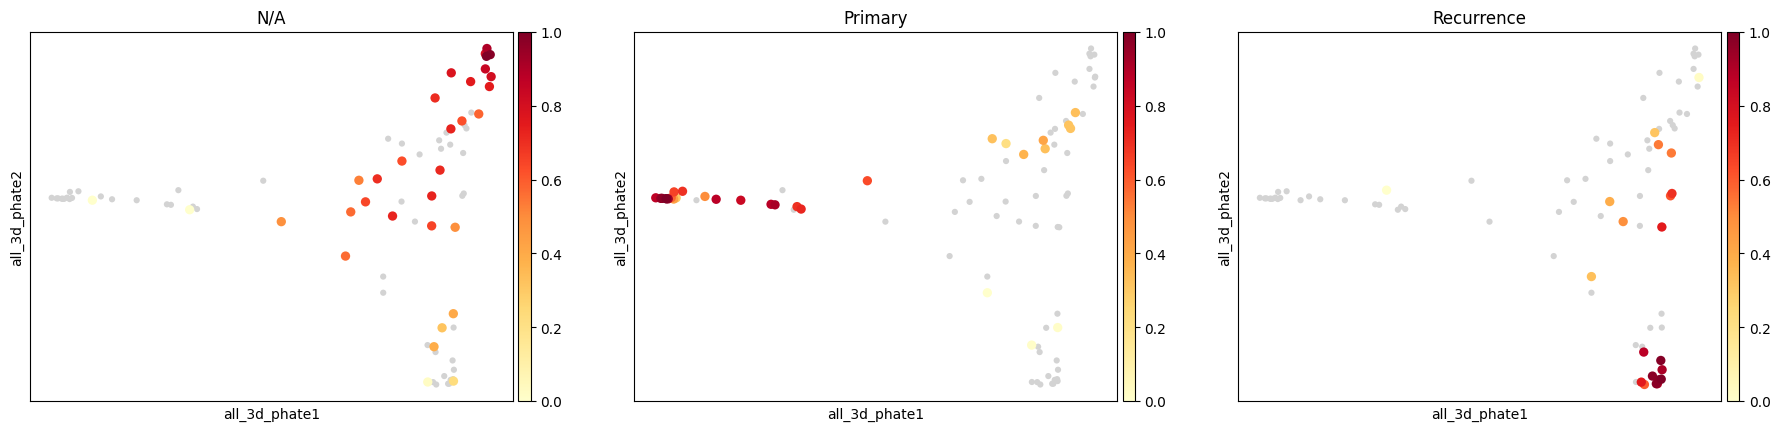

In [ ]:
sc.tl.embedding_density(adata, groupby="Clinical_status", basis='all_3d_phate',)
sc.pl.embedding_density(adata, groupby="Clinical_status", basis='all_3d_phate')

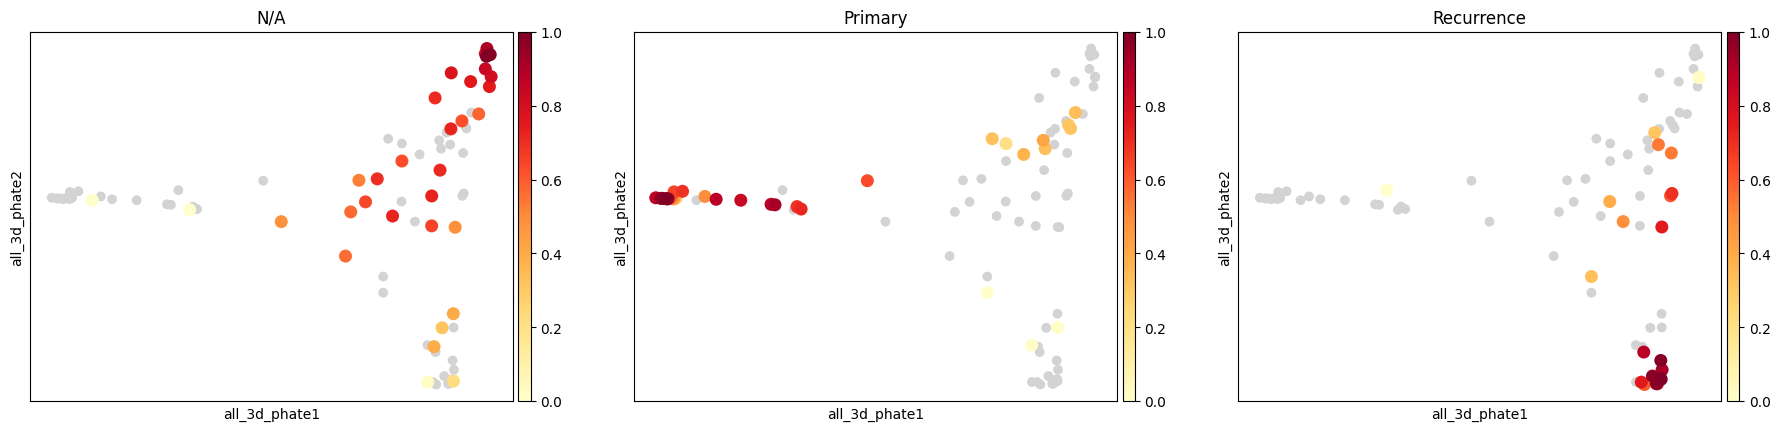

In [ ]:
import os
import scanpy as sc

# Define the path where the figure will be saved
save_path = "figures/umap_density_Clinical_status_figures"
file_name = "density_plot_beyond_pDG_atlas_pdf.pdf"

# Ensure the directory exists
os.makedirs(save_path, exist_ok=True)

# Save the plot
sc.pl.embedding_density(
    adata,
    groupby="Clinical_status",
    basis="all_3d_phate",
    bg_dotsize=200, fg_dotsize=350,
    save=os.path.join(file_name)
)